In [1]:
import pandas as pd
import numpy as np
import plotly.io as pio
import matplotlib.pyplot as plt
import os

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

os.makedirs('visualisasi', exist_ok=True)
os.makedirs('model', exist_ok=True)

print("Import selesai.")

c:\skripsi\model\BERTopic_skripsi\BERTopic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import selesai.


In [2]:
df = pd.read_csv('data_X_dan_news/x_data_BERTopic_tanpa_stopword.csv')
docs = df['final_bertopic'].tolist()

print(f"Jumlah dokumen: {len(docs)}")
print(f"Contoh dokumen pertama: {docs[0]}")

Jumlah dokumen: 1882
Contoh dokumen pertama: mau performa mesin maksimal tanpa boros bensin pelajari dulu panduan campuran etanol bbm berdasarkan studi dan fakta nyata performamesin bbmetanol efisiensibahanbakar otomotif ecodriving


In [3]:
embedding_model = SentenceTransformer('distiluse-base-multilingual-cased')
print("Embedding model siap.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 900.38it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   


Embedding model siap.


In [4]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(ngram_range=(1, 2))

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

print("Konfigurasi model selesai.")

Konfigurasi model selesai.


In [5]:
topics, probs = topic_model.fit_transform(docs)

print(f"Training selesai.")
print(f"Jumlah topik terbentuk: {len(topic_model.get_topic_info()) - 1}")

2026-06-09 22:04:42,768 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 59/59 [00:22<00:00,  2.64it/s]
2026-06-09 22:05:05,161 - BERTopic - Embedding - Completed ✓
2026-06-09 22:05:05,162 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 22:05:17,258 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:05:17,259 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:05:17,373 - BERTopic - Cluster - Completed ✓
2026-06-09 22:05:17,382 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:05:17,494 - BERTopic - Representation - Completed ✓


Training selesai.
Jumlah topik terbentuk: 23


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(26))

print("\nKata kunci per topik:\n")
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = topic_model.get_topic(topic_id)
        print(f"Topik {topic_id}: {[w for w, _ in words[:10]]}")

    Topic  Count                                               Name  \
0      -1    841                              -1_etanol_bbm_yang_di   
1       0    193                 0_indonesia_di_di indonesia_etanol   
2       1     94        1_etanol_bahlil_bahlil etanol_etanol bahlil   
3       2     92                               2_air_etanol_yang_di   
4       3     70                            3_yang_rakyat_bbm_tidak   
5       4     68                      4_lebih_kendaraan_pada_korosi   
6       5     49                           5_dari_jerami_etanol_bio   
7       6     46                6_swasta_spbu swasta_pertamina_spbu   
8       7     43                       7_etanol_sama_etanol ini_sih   
9       8     40                           8_harga_lebih_yang_mahal   
10      9     40                      9_kendaraan_etanol_yang_mesin   
11     10     36         10_menteri_esdm_lahadalia_bahlil lahadalia   
12     11     35               11_tidak_jangan_etanol_etanol jangan   
13    

C_v Coherence Score: 0.6051


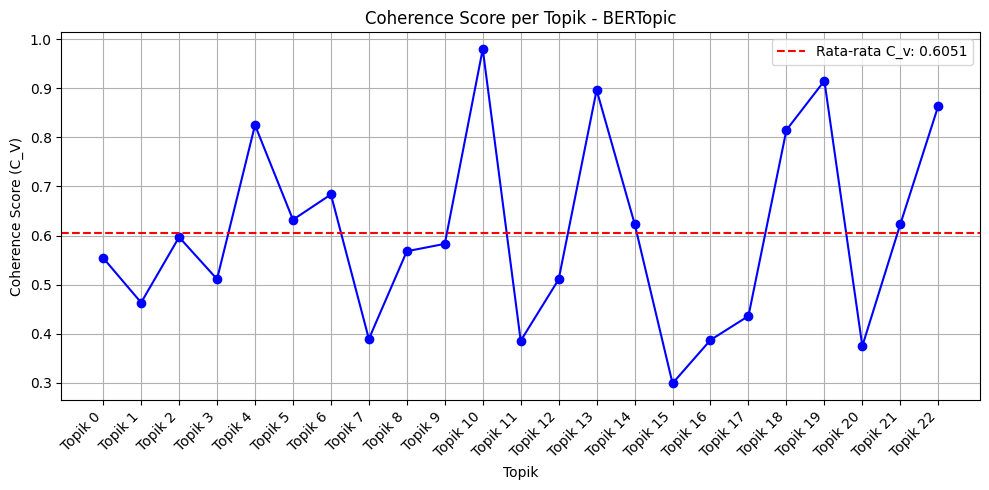

In [7]:
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)

topics_words = []
topic_ids = []
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        topics_words.append(words)
        topic_ids.append(topic_id)

if topics_words:
    cv_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cv_score = cv_model.get_coherence()
    cv_per_topic = cv_model.get_coherence_per_topic()

    print(f"C_v Coherence Score: {cv_score:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(
        [f"Topik {t}" for t in topic_ids],
        cv_per_topic,
        marker='o', color='b'
    )
    plt.axhline(y=cv_score, color='red', linestyle='--',
                label=f'Rata-rata C_v: {cv_score:.4f}')
    plt.xlabel('Topik')
    plt.ylabel('Coherence Score (C_V)')
    plt.title('Coherence Score per Topik - BERTopic')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('hasil_bertopic_x/coherence_score_bertopic_x.png', dpi=150)
    plt.show()
else:
    print("Tidak ada topik yang terbentuk.")

In [8]:
def topic_diversity(topic_model, topics, top_n=10):
    topics_words = []
    for topic_id in set(topics):
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
            topics_words.append(words)

    all_words = [word for topic in topics_words for word in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words) if all_words else 0
    return diversity

td_score = topic_diversity(topic_model, topics)
print(f"Topic Diversity: {td_score:.4f}")

Topic Diversity: 0.7087


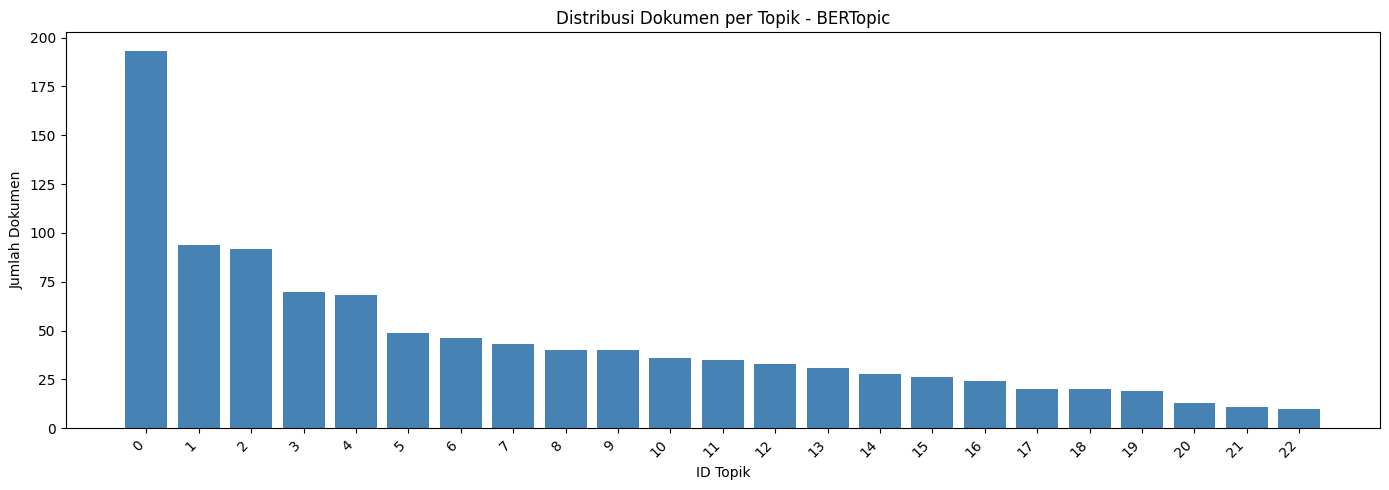

Visualisasi selesai.


In [9]:
# Topic-Word Scores
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10)
pio.write_html(fig_barchart, 'hasil_bertopic_x/barchart_topik_x.html')

# Intertopic Distance Map
fig_topics = topic_model.visualize_topics()
pio.write_html(fig_topics, 'hasil_bertopic_x/intertopic_distance_x.html')

# Distribusi dokumen per topik
topic_info_clean = topic_model.get_topic_info()
topic_info_clean = topic_info_clean[topic_info_clean['Topic'] != -1]

plt.figure(figsize=(14, 5))
plt.bar(
    topic_info_clean['Topic'].astype(str),
    topic_info_clean['Count'],
    color='steelblue'
)
plt.xlabel('ID Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Dokumen per Topik - BERTopic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hasil_bertopic_x/distribusi_dokumen_per_topik_x.png', dpi=150)
plt.show()

print("Visualisasi selesai.")

In [10]:
topic_model.save(
    "hasil_bertopic_x/model/bertopic_model",
    serialization="safetensors",
    save_embedding_model=False,
    save_ctfidf=True
)

loaded_model = BERTopic.load(
    "hasil_bertopic_x/model/bertopic_model",
    embedding_model=embedding_model
)

print("Model berhasil disimpan dan diverifikasi.")

2026-06-09 22:05:27,167 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Model berhasil disimpan dan diverifikasi.
